In [77]:
import starsim as ss
import stisim as sti
import matplotlib.pyplot as plt
import sciris as sc
import numpy as np
import pandas as pd

# Part 1: Getting started

## Hello World

Initializing sim with 1000 agents
Figure(800x600)


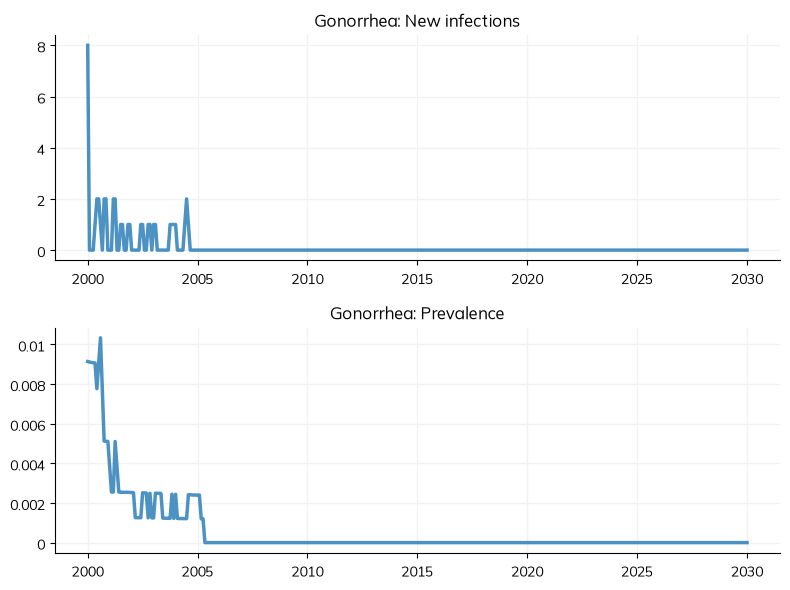

In [2]:
sim = sti.Sim(diseases='ng')
sim.run(verbose=0)
sim.plot(key=['ng.new_infections', 'ng.prevalence'])

## Inspect Simulation Parameters

In [5]:
## Inspect Simulation Parameters

sim = sti.Sim(diseases='ng')
sim.init()

print(f'Start:    {sim.pars.start}')
print(f'Stop:     {sim.pars.stop}')
print(f'Timestep: {sim.pars.dt} years ({sim.pars.dt*12:.0f} month)')
print(f'Agents:   {sim.pars.n_agents}')

Initializing sim with 1000 agents
Start:    2000
Stop:     2030
Timestep: 0.08333333333333333 years (1 month)
Agents:   1000


## Networks

In [6]:
for name, nw in sim.networks.items():
     print(f'{name}: {type(nw).__name__}')

structuredsexual: StructuredSexual
maternalnet: MaternalNet


## Disease

In [7]:
ng = sim.diseases.ng
print(f'Disease: {type(ng).__name__}')
print(f'Transmission (M to F): {ng.pars.beta_m2f}')
print(f'Initial prevalence: {ng.pars.init_prev}')
print(f'Condom efficacy: {ng.pars.eff_condom}')

Disease: Gonorrhea
Transmission (M to F): 0.06
Initial prevalence: ss.bernoulli(p=0.01)
Condom efficacy: 0.9


## Customizing the simulation

### Passing parameters inline

In [9]:
sim = sti.Sim(
    diseases='ng',
    n_agents=2000,
    start=2010,
    stop=2025,
)
sim.run(verbose=0)

Initializing sim with 2000 agents


Sim(n=2000; 2010—2025; networks=structuredsexual, maternalnet; diseases=ng)

### Passing disease-specific parameters using sti_pars
Overwrites disease defaults without creating disease object myself

In [14]:
sti_pars=dict(
    ng=dict(init_prev=0.05),
    ct=dict(init_prev=0.08)
)

sim = sti.Sim(
    diseases=['ng', 'ct'],
    sti_pars = sti_pars)

sim.run(verbose=0)

Initializing sim with 1000 agents


Sim(n=1000; 2000—2030; networks=structuredsexual, maternalnet; diseases=ng, ct)

## Exercises

### Exercise 1: 

Create a sim with both gonorrhea and chlamydia. Run it and plot the results.

Initializing sim with 2000 agents
Figure(800x600)


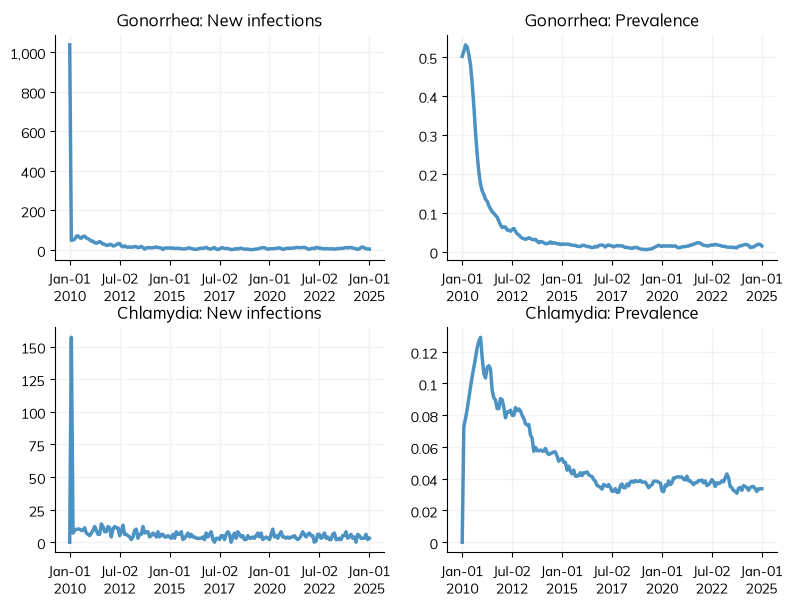

In [30]:
sti_pars=dict(
    ng=dict(init_prev=0.5),
    ct=dict(init_prev=0.08)
)

sim = sti.Sim(
    diseases = ['ng', 'ct'],
    n_agents = 2000,
    sti_pars=sti_pars,
    start=2010,
    stop=2025,
)
sim.run(verbose=0)

sim.plot(key=['ng.new_infections', 'ng.prevalence', 'ct.new_infections', 'ct.prevalence'])

### Exercise 2: 

Try changing the gonorrhea transmission rate (beta_m2f) from 0.06 to 0.15 and observe how it affects prevalence.

Initializing sim with 2000 agents
Figure(800x600)


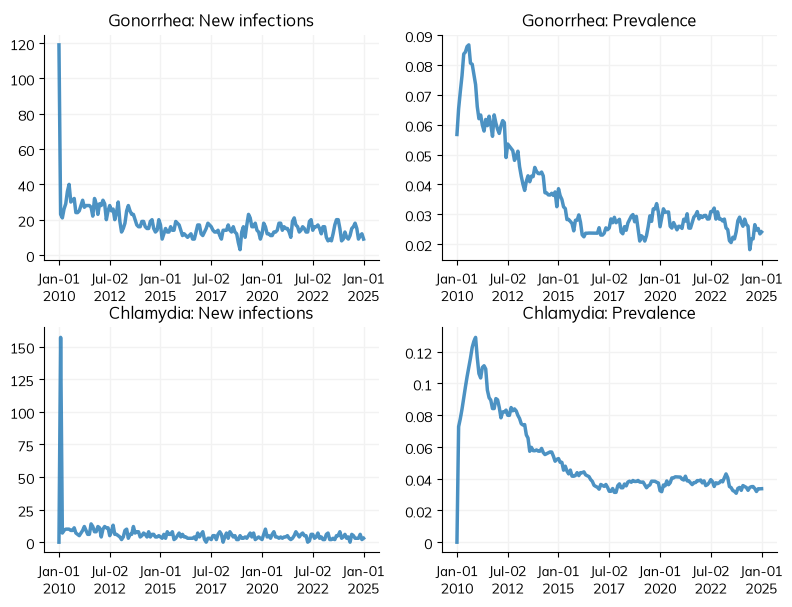

In [29]:
sti_pars=dict(
    ng=dict(init_prev=0.05, beta_m2f = 0.15),
    ct=dict(init_prev=0.08)
)

sim = sti.Sim(
    diseases = ['ng', 'ct'],
    n_agents = 2000,
    sti_pars=sti_pars,
    start=2010,
    stop=2025,
)
sim.run(verbose=0)

sim.plot(key=['ng.new_infections', 'ng.prevalence', 'ct.new_infections', 'ct.prevalence'])

### Exercise 3: 

Add demographics by passing demographics='zimbabwe' and compare the results to the default (no demographics) sim.

In [ ]:
demographics = 'zimbabwe'

sti_pars=dict(
    ng=dict(init_prev=0.05, beta_m2f = 0.15),
    ct=dict(init_prev=0.08)
)

sim = sti.Sim(
    diseases = ['ng', 'ct'],
    n_agents = 2000,
    sti_pars=sti_pars,
    demographics=demographics,
    start=2010,
    stop=2025,
)
sim.run(verbose=0)

sim.plot(key=['ng.new_infections', 'ng.prevalence', 'ct.new_infections', 'ct.prevalence'])

# Part 2: Results and Plotting

## Setup

Run a simple ng simulation to start:

In [33]:
sim = sti.Sim(diseases='ng', n_agents=2000, start=2010, stop=2030)
sim.run(verbose=0)

Initializing sim with 2000 agents


Sim(n=2000; 2010—2030; networks=structuredsexual, maternalnet; diseases=ng)

Available results are now stored in `sim.results`. Each disease has its own results object, accessible through `.keys()`

In [37]:
sim.results.ng.keys()[:5]

['timevec', 'n_susceptible', 'n_infected', 'n_exposed', 'n_asymptomatic']

In [38]:
# Access individual results
prev = sim.results.ng.prevalence
print(f'{prev.label}: min={prev.values.min():.3f}, mean={prev.values.mean():.3f}, max={prev.values.max():.3f}')

new_inf = sim.results.ng.new_infections
print(f'{new_inf.label}: min={new_inf.values.min():.0f}, mean={new_inf.values.mean():.1f}, max={new_inf.values.max():.0f}')

# There are many more -- including by sex and age group
print(f'\nTotal result keys: {len(sim.results.ng.keys())}')

Prevalence: min=0.000, mean=0.001, max=0.009
New infections: min=0, mean=0.2, max=16

Total result keys: 204


## Automatic plotting

Figure(933.333x700)


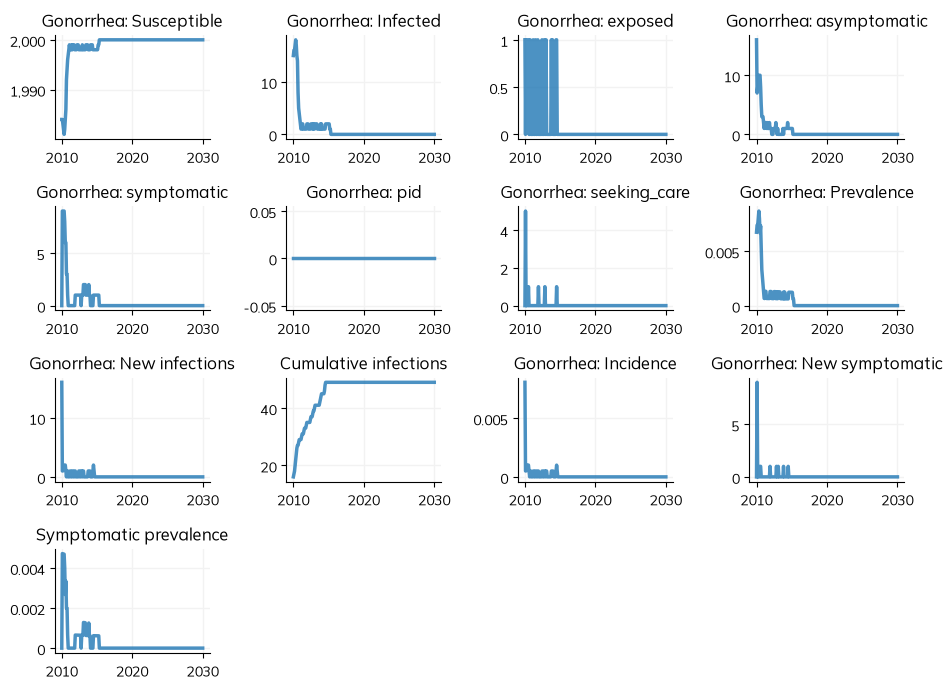

In [39]:
sim.plot()

## Plotting specific results

Figure(800x600)


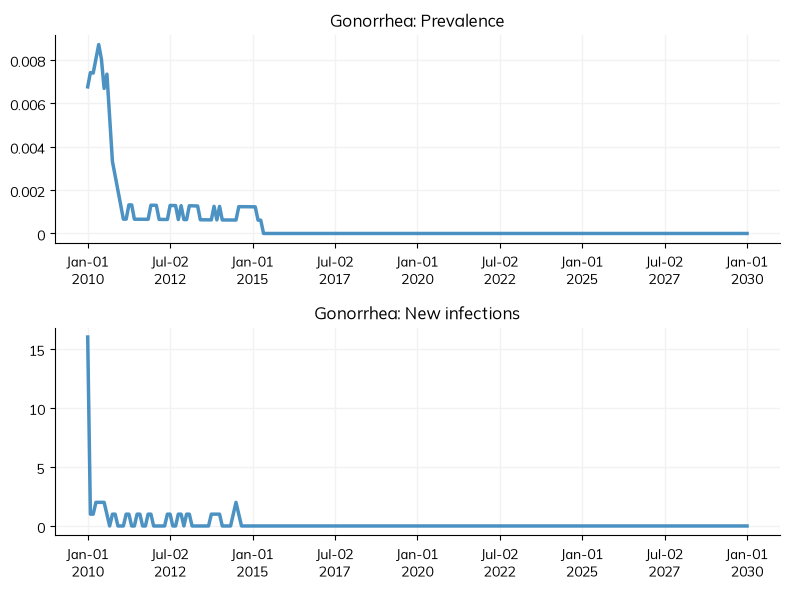

In [41]:
# Plot just prevalence and new infections
sim.plot(key=['ng.prevalence', 'ng.new_infections'])

## Exporting results as a dataframe

In [42]:
df = sim.to_df()
print(f'Shape: {df.shape}')
df.head()

Shape: (241, 211)


,timevec,structuredsexual_n_edges,maternalnet_n_edges,ng_n_susceptible,ng_n_infected,ng_n_exposed,ng_n_asymptomatic,ng_n_symptomatic,ng_n_pid,ng_n_seeking_care,...,ng_new_symptomatic_m_50_65,ng_symp_prevalence_m_50_65,ng_new_symptomatic_m_65_100,ng_symp_prevalence_m_65_100,ng_rel_treat,n_alive,n_female,new_deaths,new_emigrants,cum_deaths
0,2010-01-01,228.0,0.0,1984.0,15.0,1.0,16.0,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,2000.0,964.0,0.0,0.0,0.0
1,2010-01-31,267.0,0.0,1984.0,16.0,0.0,7.0,9.0,0.0,5.0,...,1.0,0.005988,0.0,0.0,0.0,2000.0,964.0,0.0,0.0,0.0
2,2010-03-03,365.0,0.0,1983.0,16.0,1.0,8.0,9.0,0.0,0.0,...,0.0,0.005952,0.0,0.0,0.0,2000.0,964.0,0.0,0.0,0.0
3,2010-04-02,398.0,0.0,1982.0,17.0,1.0,9.0,9.0,0.0,1.0,...,0.0,0.005917,0.0,0.0,0.0,2000.0,964.0,0.0,0.0,0.0
4,2010-05-03,398.0,0.0,1981.0,18.0,1.0,10.0,9.0,0.0,0.0,...,0.0,0.005780,0.0,0.0,0.0,2000.0,964.0,0.0,0.0,0.0


## Resampling to annual results
STIsim runs with monthly timesteps by default, but you’ll often want annual results for reporting or comparison with data. Use the resample() method on any result:

In [43]:
# Monthly new infections (raw)
monthly = sim.results.ng.new_infections
print(f'Monthly: {len(monthly.values)} timesteps')

# Resample to annual (sums monthly counts)
annual = monthly.resample('year')
print(f'Annual:  {len(annual)} years')
print(annual)

Monthly: 241 timesteps
Annual:  21 years
Result(Gonorrhea.new_infections: min=0, mean=2.33333, max=29)


## Plotting with Matplotlib

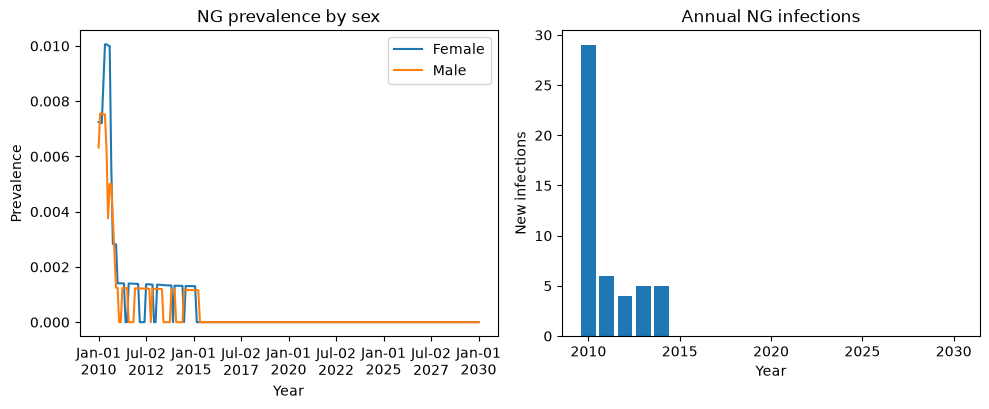

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Left: prevalence by sex
axes[0].plot(sim.timevec, sim.results.ng.prevalence_f, label='Female')
axes[0].plot(sim.timevec, sim.results.ng.prevalence_m, label='Male')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Prevalence')
axes[0].set_title('NG prevalence by sex')
axes[0].legend()

# Right: annual new infections (resampled)
annual_inf = sim.results.ng.new_infections.resample('year', use_years=True)
axes[1].bar(annual_inf.timevec, annual_inf.values)
axes[1].set_xlabel('Year')
axes[1].set_ylabel('New infections')
axes[1].set_title('Annual NG infections')

plt.tight_layout()
fig

## Custom results

STISim's built-in results cover the most common quantities (prevalence, incidence, etc).

Also possible to define custom results: **analyzers, interventions, networks, connnectors, and diseases** all use the same `define_results` pattern.  The example below shows a custom analyzer which tracksng prevalence among people aged 15-24

In [48]:
class YouthPrev(ss.Analyzer):
    """Track gonorrhea prevalence among 15-24 year olds."""

    def init_pre(self, sim):
        super().init_pre(sim)
        # define_results registers a result with the sim's results system.
        # After sim.run(), it appears in sim.results.youthprev.ng_prev_15_24
        # and in sim.to_df() as 'youthprev.ng_prev_15_24'.
        self.define_results(
            ss.Result('ng_prev_15_24', dtype=float, scale=False, label='NG prev (15-24)'),
        )

    def step(self):
        ppl = self.sim.people
        youth = (ppl.age >= 15) & (ppl.age < 25)       # Boolean mask for 15-24 year olds
        n_youth = youth.count()                          # How many are in this group
        if n_youth > 0:
            infected = self.sim.diseases.ng.infected     # Boolean: who is infected
            prev = (infected & youth).count() / n_youth  # Prevalence = infected / total
            self.results['ng_prev_15_24'][self.ti] = prev

In [49]:
# Create the object
youth_prev = YouthPrev()
ng = sti.Gonorrhea(init_prev=ss.bernoulli(p=0.1))  # Higher init_prev so the demo has visible infections among youth

# With the simulation add the youth_prev analyzer to the list
sim = sti.Sim(diseases=ng, analyzers=youth_prev, n_agents=2000, start=2015, stop=2020)
sim.run(verbose=0)



Initializing sim with 2000 agents
Result(YouthPrev.ng_prev_15_24: min=0.00657895, mean=0.0337935, max=0.124183)


Figure(800x600)


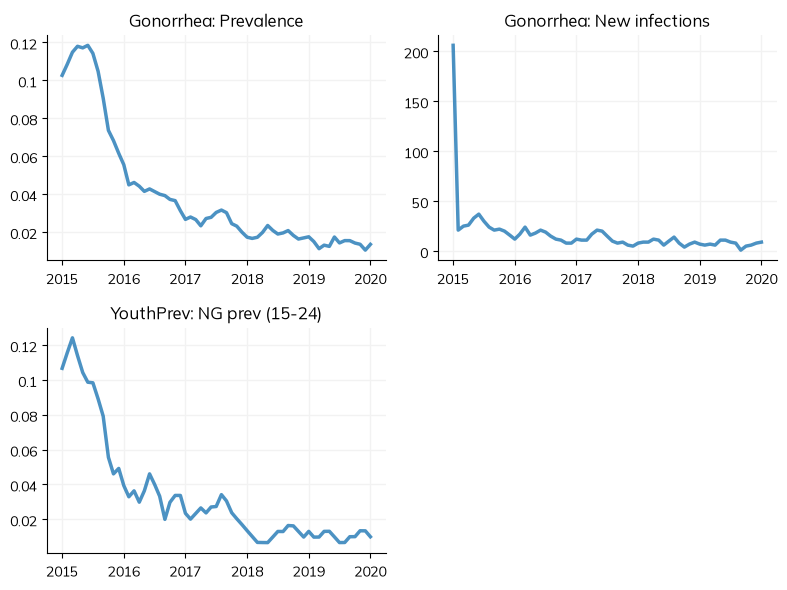

In [56]:
sim.plot(key=['ng.prevalence', 'ng.new_infections', 'youthprev.ng_prev_15_24'])

Figure(640x480)


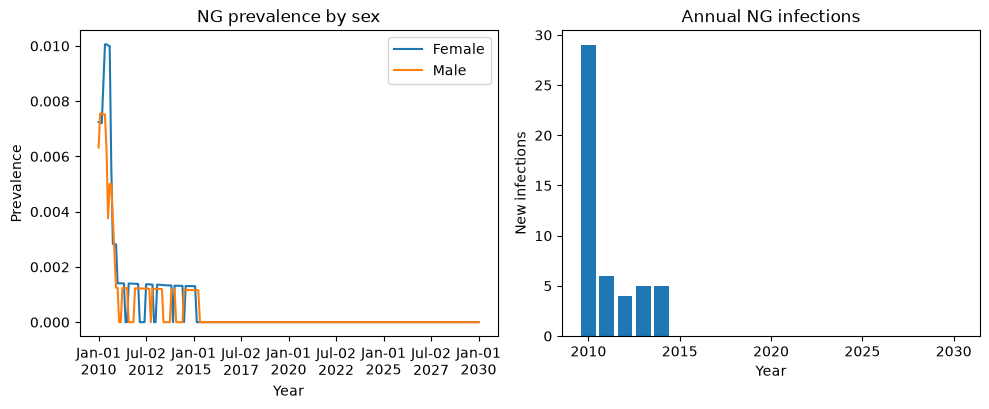

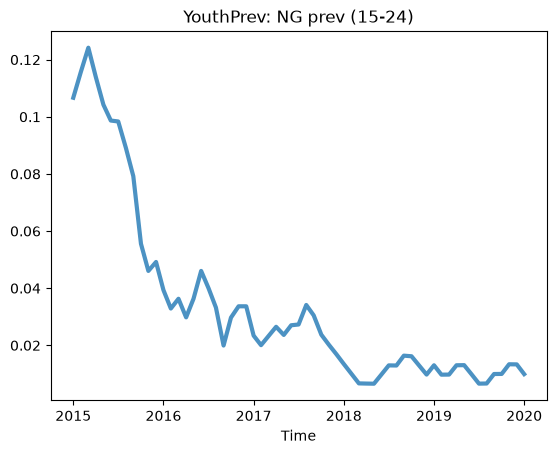

In [53]:
sim.results.youthprev.ng_prev_15_24.plot()

## Exercises

### Exercise 1

Run a sim with both 'ng' and 'ct'. Use sim.plot(key=...) to compare the prevalence of the two diseases on the same figure.

Initializing sim with 1000 agents
Figure(800x600)


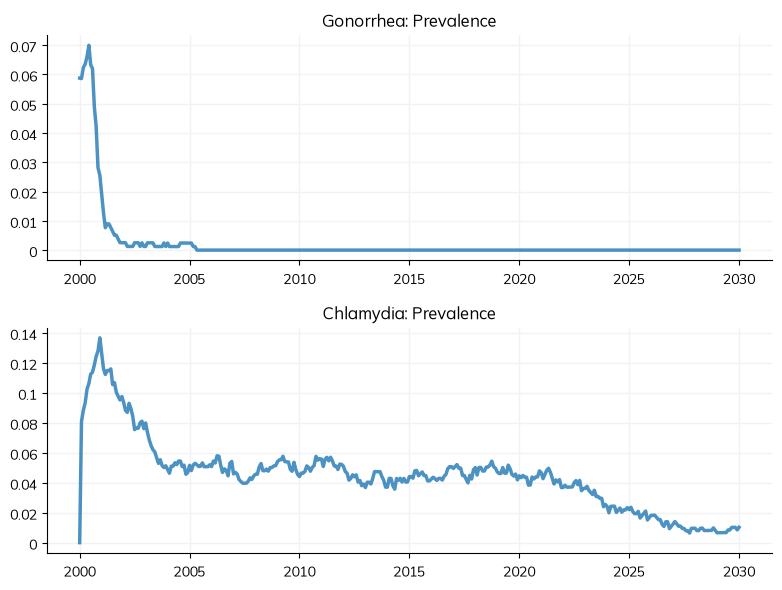

In [57]:
sti_pars=dict(
    ng=dict(init_prev=0.05),
    ct=dict(init_prev=0.08)
)

sim = sti.Sim(
    diseases=['ng', 'ct'],
    sti_pars = sti_pars)

sim.run(verbose=0)

sim.plot(key=['ng.prevalence', 'ct.prevalence'])

### Exercise 2

Convert to a dataframe

In [59]:
df = sim.to_df()
print(f'Shape: {df.shape}')
df.head()

Shape: (361, 413)


,timevec,structuredsexual_n_edges,maternalnet_n_edges,ng_n_susceptible,ng_n_infected,ng_n_exposed,ng_n_asymptomatic,ng_n_symptomatic,ng_n_pid,ng_n_seeking_care,...,ct_symp_prevalence_m_35_50,ct_new_symptomatic_m_50_65,ct_symp_prevalence_m_50_65,ct_new_symptomatic_m_65_100,ct_symp_prevalence_m_65_100,n_alive,n_female,new_deaths,new_emigrants,cum_deaths
0,2000-01-01,121.0,0.0,943.0,57.0,0.0,57.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,1000.0,500.0,0.0,0.0,0.0
1,2000-01-31,144.0,0.0,940.0,57.0,3.0,36.0,24.0,0.0,11.0,...,0.054264,0.0,0.0,0.0,0.0,1000.0,500.0,0.0,0.0,0.0
2,2000-03-02,199.0,0.0,937.0,60.0,3.0,37.0,26.0,0.0,2.0,...,0.062016,0.0,0.0,0.0,0.0,1000.0,500.0,0.0,0.0,0.0
3,2000-04-02,217.0,0.0,935.0,61.0,4.0,39.0,26.0,0.0,4.0,...,0.069231,0.0,0.0,0.0,0.0,1000.0,500.0,0.0,0.0,0.0
4,2000-05-02,213.0,0.0,931.0,63.0,6.0,42.0,27.0,0.0,3.0,...,0.078125,0.0,0.0,0.0,0.0,1000.0,500.0,0.0,0.0,0.0


### Exercise 3

Plot monthly symptomatic prevalence and total prevalence

Figure(800x600)


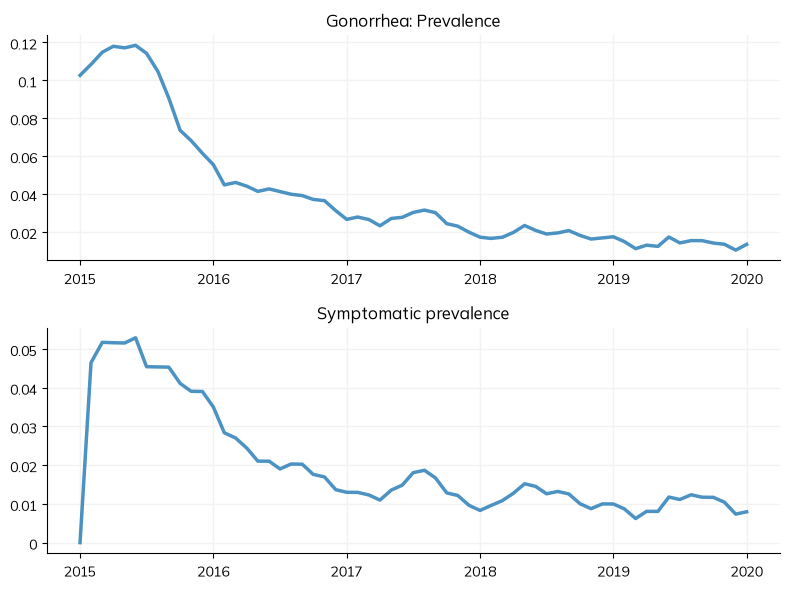

In [70]:
sim.plot(key=['ng.prevalence', 'ng.symp_prevalence'])

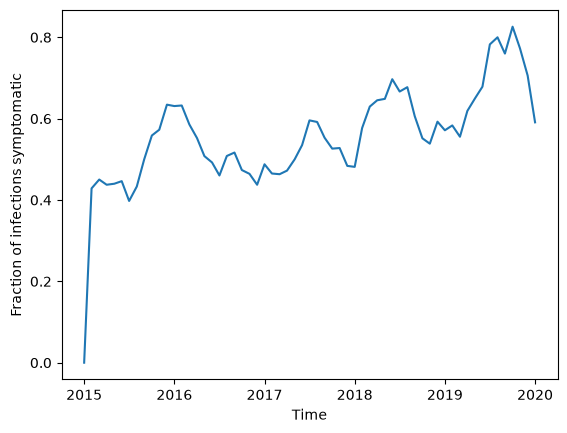

In [99]:
prev = sim.results.ng.prevalence.values
symp = sim.results.ng.symp_prevalence.values
frac = np.divide(symp, prev, out=np.full_like(prev, np.nan), where=(prev > 0))  # avoid 0/0

fig, ax = plt.subplots()
ax.plot(sim.results.ng.prevalence.timevec, frac)
ax.set_ylabel('Fraction of infections symptomatic')
ax.set_xlabel('Time')

plt.show()

### Exercise 4

Write an analyzer that tracks the number of symptomatic gonorrhea cases in males aged 25-49. Run the sim with it and verify the result appears in sim.to_df().

In [100]:
class AdultPrev(ss.Analyzer):
    """Track gonorrhea prevalence among 15-24 year olds."""

    def init_pre(self, sim):
        super().init_pre(sim)
        # define_results registers a result with the sim's results system.
        # After sim.run(), it appears in sim.results.youthprev.ng_prev_15_24
        # and in sim.to_df() as 'youthprev.ng_prev_15_24'.
        self.define_results(
            ss.Result('ng_prev_25_49', dtype=float, scale=False, label='NG prev (25-49)'),
        )

    def step(self):
        ppl = self.sim.people
        adults = (ppl.age >= 25) & (ppl.age < 50)       # Boolean mask for 15-24 year olds
        n_adults = adults.count()                          # How many are in this group
        if n_adults > 0:
            infected = self.sim.diseases.ng.infected     # Boolean: who is infected
            prev = (infected & adults).count() / n_adults  # Prevalence = infected / total
            self.results['ng_prev_25_49'][self.ti] = prev

In [65]:
# Create the object
adult_prev = AdultPrev()
ng = sti.Gonorrhea(init_prev=ss.bernoulli(p=0.1))  # Higher init_prev so the demo has visible infections among youth

# With the simulation add the youth_prev analyzer to the list
sim = sti.Sim(diseases=ng, analyzers=[youth_prev, adult_prev], n_agents=2000, start=2015, stop=2020)
sim.run(verbose=0)

Initializing sim with 2000 agents


Sim(n=2000; 2015—2020; networks=structuredsexual, maternalnet; diseases=ng; analyzers=youthprev, adultprev)

In [88]:
df = sim.to_df()

df.loc[:, ["timevec", "adultprev_ng_prev_25_49", "youthprev_ng_prev_15_24"]]

,timevec,adultprev_ng_prev_25_49,youthprev_ng_prev_15_24
0,2015-01-01,0.101896,0.106667
1,2015-01-31,0.108205,0.115512
2,2015-03-03,0.116806,0.124183
3,2015-04-02,0.127685,0.114007
4,2015-05-03,0.136691,0.104235
...,...,...,...
56,2019-09-01,0.026097,0.009967
57,2019-10-02,0.023725,0.010000
58,2019-11-01,0.021277,0.013378
59,2019-12-02,0.015366,0.013333


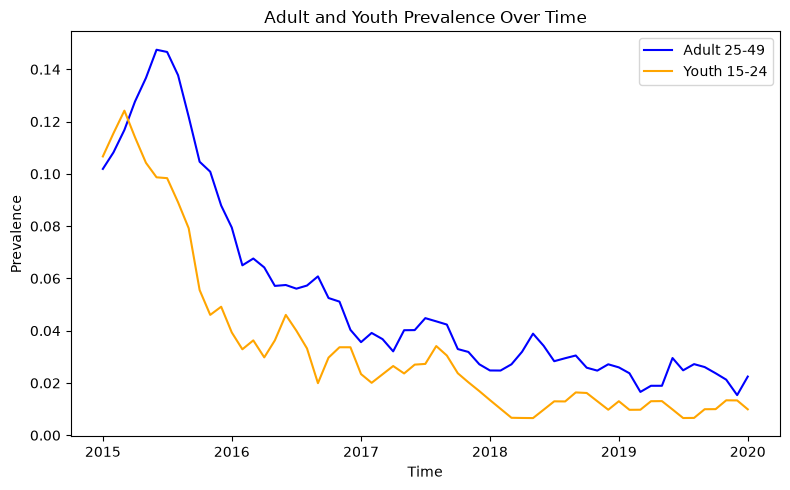

In [96]:
df["timevec"] = pd.to_datetime(df["timevec"])

plt.figure(figsize=(8, 5))
plt.plot(df["timevec"], df["adultprev_ng_prev_25_49"], label="Adult 25-49", color="blue")
plt.plot(df["timevec"], df["youthprev_ng_prev_15_24"], label="Youth 15-24", color="orange")

plt.xlabel("Time")
plt.ylabel("Prevalence")
plt.title("Adult and Youth Prevalence Over Time")
plt.legend()
plt.tight_layout()
plt.show()

# Part 3: Interventions

## Add testing and treatment interventions to an STIsim simulation.

### Simple STI treatment: baseline case with no treatment

In [4]:
# Baseline: no treatment
ng = sti.Gonorrhea(init_prev=0.01)
sim_base = sti.Sim(diseases=ng, n_agents=2000, start=2010, stop=2030)
sim_base.run(verbose=0)


Initializing sim with 2000 agents


Sim(n=2000; 2010—2030; networks=structuredsexual, maternalnet; diseases=ng)

### Simple STI treatment: symptomatic care-seekers get treated

In [5]:
# With treatment: symptomatic care-seekers get treated
# logic of eligibility is that the time of seeking care equals the current time, and symptomatic
ng_tx = sti.GonorrheaTreatment(
    name='ng_tx',
    eligibility=lambda sim: sim.diseases.ng.symptomatic & (sim.diseases.ng.ti_seeks_care == sim.ti),
)

sim_intv = sti.Sim(diseases=ng, interventions=[ng_tx], n_agents=2000, start=2010, stop=2030)
sim_intv.run(verbose=0)

Initializing sim with 2000 agents


Sim(n=2000; 2010—2030; networks=structuredsexual, maternalnet; diseases=ng; interventions=ng_tx)

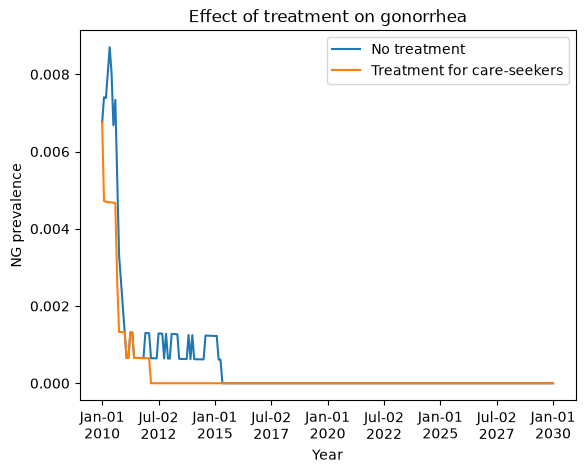

In [10]:
fig, ax = plt.subplots()
ax.plot(sim_base.timevec, sim_base.results.ng.prevalence, label='No treatment')
ax.plot(sim_intv.timevec, sim_intv.results.ng.prevalence, label='Treatment for care-seekers')
ax.set_xlabel('Year')
ax.set_ylabel('NG prevalence')
ax.set_title('Effect of treatment on gonorrhea')
ax.legend()

plt.show()

## HIV Testing and ART

HIV interventions follow a specific pipeline: testing → diagnosis → ART initiation. Agents must be diagnosed by HIVTest before they can start ART.

Key things to know: - test_prob_data is a per-year probability, automatically scaled by timestep. With monthly dt, test_prob_data=0.1 means ~0.83% per month (~10% per year). - ART(coverage=0.8) will force-fit 80% of infected onto ART. ART() with no coverage treats everyone who is diagnosed. - art_initiation (default 90%) controls how many newly diagnosed agents are willing to start ART.

In [11]:
import hivsim

# Simplest approach: use hivsim.demo which includes testing + ART by default
sim_default = hivsim.demo('simple', run=False, plot=False, n_agents=3000)
sim_default.run(verbose=0)

# Custom: specify coverage explicitly
hiv_test = sti.HIVTest(test_prob_data=0.2, start=2000, name='hiv_test')

# ART with time-varying coverage (proportion of infected)
art = sti.ART(coverage={'year': [2000, 2010, 2025], 'value': [0, 0.5, 0.9]})

# Without any interventions for comparison
sim_base = hivsim.demo('simple', run=False, plot=False, n_agents=3000)
sim_base.pars.interventions = []
sim_base.run(verbose=0)

# With custom testing + ART
sim_intv = hivsim.demo('simple', run=False, plot=False, n_agents=3000)
sim_intv.pars.interventions = [hiv_test, art]
sim_intv.run(verbose=0)

Initializing sim with 3000 agents
Initializing sim with 3000 agents
Initializing sim with 3000 agents


Sim(n=3000; 2000—2020.0; demographics=pregnancy, deaths; networks=mfnetwork, maternalnet, breastfeedingnet; diseases=hiv; interventions=hiv_test, art)

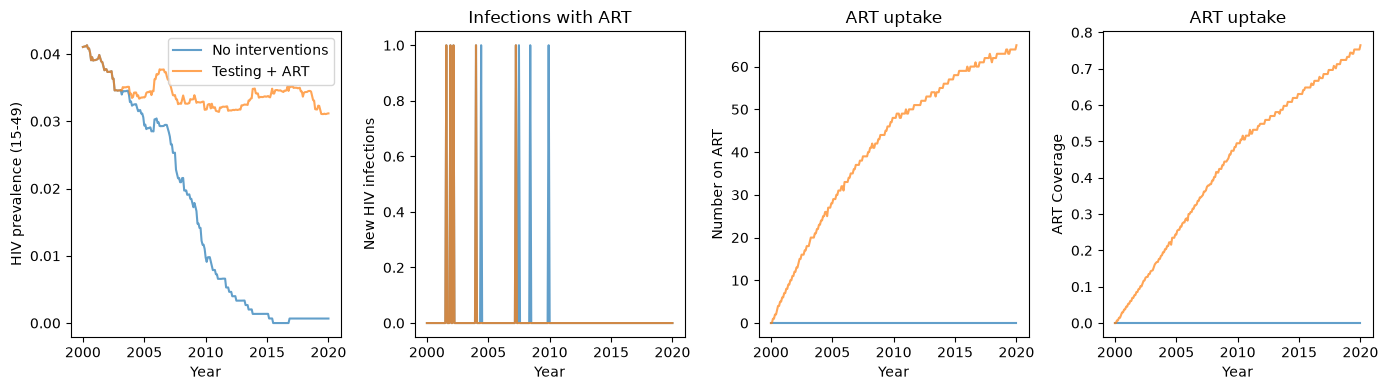

In [24]:
fig, axes = plt.subplots(1, 4, figsize=(14, 4))

axes[0].plot(sim_base.timevec, sim_base.results.hiv.prevalence_15_49, label='No interventions', alpha=0.7)
axes[0].plot(sim_intv.timevec, sim_intv.results.hiv.prevalence_15_49, label='Testing + ART', alpha=0.7)
axes[0].set_xlabel('Year')
axes[0].set_ylabel('HIV prevalence (15-49)')
axes[0].legend()

axes[1].plot(sim_intv.timevec, sim_base.results.hiv.new_infections, label='No interventions', alpha=0.7)
axes[1].plot(sim_intv.timevec, sim_intv.results.hiv.new_infections, label='Testing + ART', alpha=0.7)
axes[1].set_xlabel('Year')
axes[1].set_ylabel('New HIV infections')
axes[1].set_title('Infections with ART')

axes[2].plot(sim_intv.timevec, sim_base.results.hiv.n_on_art, label='No interventions', alpha=0.7)
axes[2].plot(sim_intv.timevec, sim_intv.results.hiv.n_on_art, label='Testing + ART', alpha=0.7)
axes[2].set_xlabel('Year')
axes[2].set_ylabel('Number on ART')
axes[2].set_title('ART uptake')


axes[3].plot(sim_intv.timevec, sim_base.results.hiv.n_on_art/sim_base.results.hiv.n_infected, label='No interventions', alpha=0.7)
axes[3].plot(sim_intv.timevec, sim_intv.results.hiv.n_on_art/sim_intv.results.hiv.n_infected, label='Testing + ART', alpha=0.7)
axes[3].set_xlabel('Year')
axes[3].set_ylabel('ART Coverage')
axes[3].set_title('ART uptake')

plt.tight_layout()

plt.show()

## Targeting Interventions

Target specific populations for interventions using the `eligibility` parameter (seems similar to `targeting_config` from EMOD)

Initializing sim with 3000 agents
Figure(800x600)


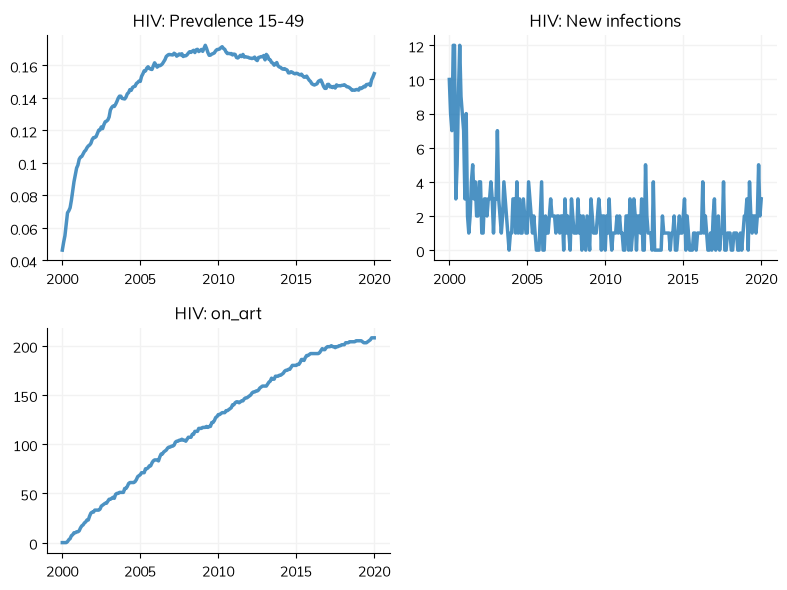

In [34]:
# Higher testing rate for FSWs
fsw_test = sti.HIVTest(
    test_prob_data=0.3,
    start=2000,
    name='fsw_test',
    eligibility=lambda sim: sim.networks.structuredsexual.fsw & ~sim.diseases.hiv.diagnosed,
)

# Lower testing rate for the general population
gp_test = sti.HIVTest(
    test_prob_data=0.05,
    start=2000,
    name='gp_test',
    eligibility=lambda sim: ~sim.networks.structuredsexual.fsw & ~sim.diseases.hiv.diagnosed,
)

art2 = sti.ART(coverage=0.8)

# Use StructuredSexual so `fsw` is available on the network (hivsim.demo('simple')
# now uses MFNetwork by default, which has no sex-work compartment)
sim = hivsim.demo('simple', run=False, plot=False, n_agents=3000,
                  networks=[sti.StructuredSexual(), ss.MaternalNet(), ss.BreastfeedingNet()])
sim.pars.interventions = [fsw_test, gp_test, art2]
sim.run(verbose=0)
sim.plot(key=['hiv.prevalence_15_49', 'hiv.new_infections', 'hiv.n_on_art'])

Initializing sim with 3000 agents
Figure(800x600)


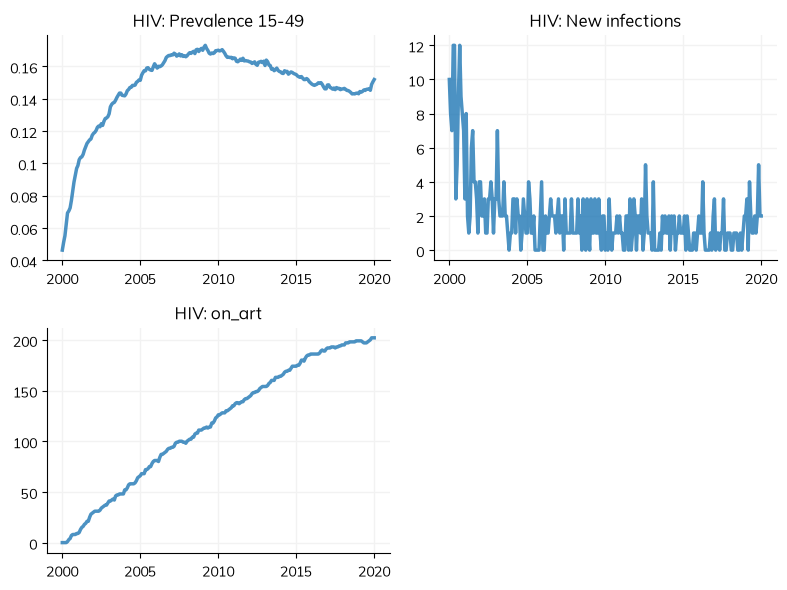

In [31]:
# Compare the above to a case where we don't have differentiated testing

gp_test = sti.HIVTest(
    test_prob_data=0.05,
    start=2000,
    name='gp_test',
    eligibility=lambda sim: ~sim.diseases.hiv.diagnosed,
)
art2 = sti.ART(coverage=0.8)

# Use StructuredSexual so `fsw` is available on the network (hivsim.demo('simple')
# now uses MFNetwork by default, which has no sex-work compartment)
sim_base = hivsim.demo('simple', run=False, plot=False, n_agents=3000,
                  networks=[sti.StructuredSexual(), ss.MaternalNet(), ss.BreastfeedingNet()])
sim_base.pars.interventions = [gp_test, art2]
sim_base.run(verbose=0)
sim_base.plot(key=['hiv.prevalence_15_49', 'hiv.new_infections', 'hiv.n_on_art'])

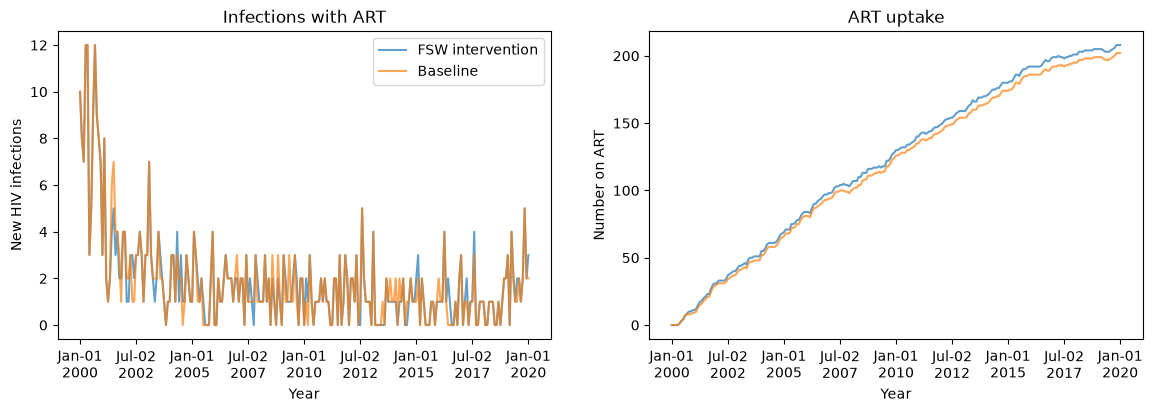

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(sim.timevec, sim.results.hiv.new_infections, label='FSW intervention', alpha=0.7)
axes[0].plot(sim_base.timevec, sim_base.results.hiv.new_infections, label='Baseline', alpha=0.7)
axes[0].set_xlabel('Year')
axes[0].set_ylabel('New HIV infections')
axes[0].set_title('Infections with ART')
axes[0].legend()

axes[1].plot(sim.timevec, sim.results.hiv.n_on_art, label='FSW intervention', alpha=0.7)
axes[1].plot(sim_base.timevec, sim_base.results.hiv.n_on_art, label='Baseline', alpha=0.7)
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Number on ART')
axes[1].set_title('ART uptake')

plt.show()

## ART coverage formats and monitoring

Did you know that there's an `art_coverage` analyzer?

There are three ART coverage formats - constant coverage, coverage by year, and treat all who are diagnosed (UTT)

In [36]:
# Different coverage formats
art_const = sti.ART(coverage=0.8)                                                     # Constant proportion
art_dict  = sti.ART(coverage={'year': [2000, 2010, 2025], 'value': [0, 0.5, 0.9]})   # Time-varying
art_none  = sti.ART()                                                                  # No target: treat all diagnosed

# Run with the art_coverage analyzer to monitor coverage by age/sex
sim = hivsim.demo('simple', run=False, plot=False, n_agents=5000)
sim.pars.interventions = [sti.HIVTest(test_prob_data=0.3, name='hiv_test'), art_dict]
sim.pars.analyzers = [sti.art_coverage(age_bins=[15, 25, 35, 45, 65])]
sim.run(verbose=0)

Initializing sim with 5000 agents


Sim(n=5000; 2000—2020.0; demographics=pregnancy, deaths; networks=mfnetwork, maternalnet, breastfeedingnet; diseases=hiv; interventions=hiv_test, art; analyzers=art_coverage)

### 1. Use the built-in plot method to inspect results

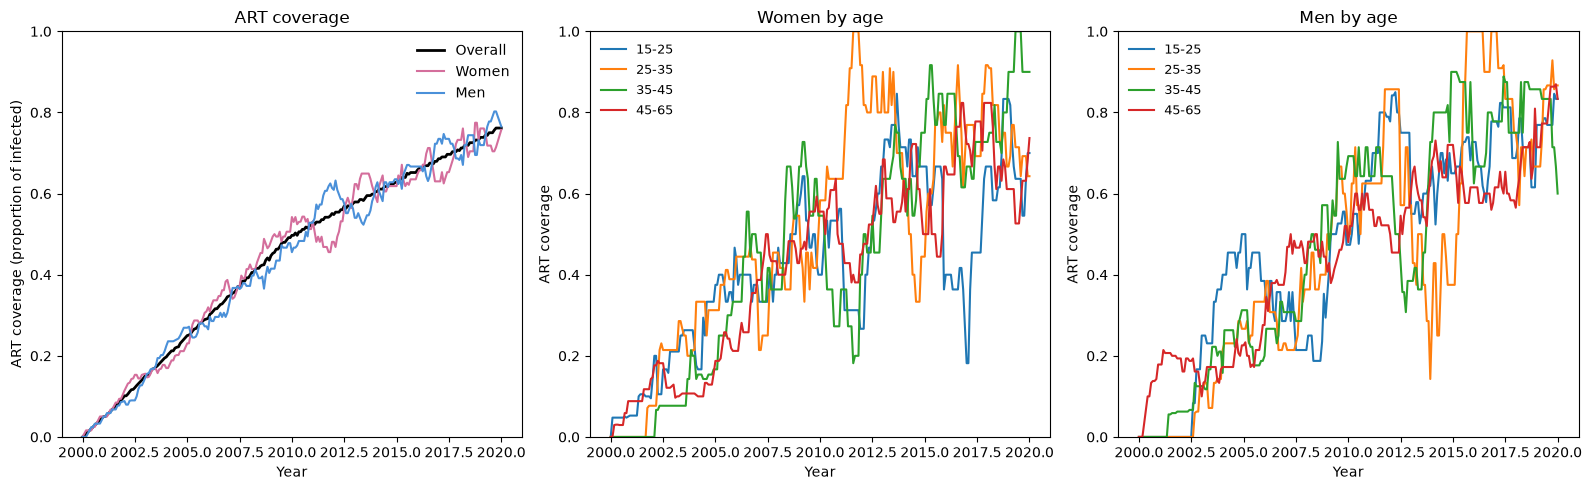

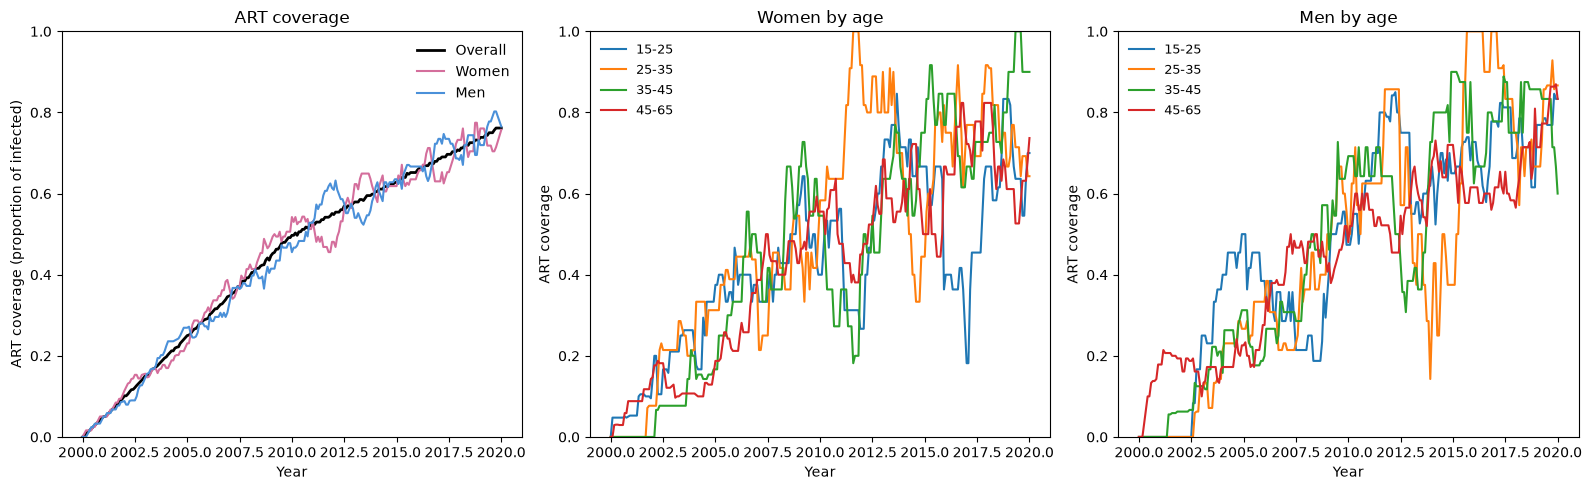

In [41]:
### 1. Use the built-in plot method to inspect results
sim.analyzers.art_coverage.plot()

### 2. Access results directly

In [38]:
### 2. Access results directly
ac = sim.results.art_coverage
print(f'Final overall ART coverage: {ac.p_art[-1]:.1%}')
print(f'Final coverage, women 25-35: {ac.p_art_f_25_35[-1]:.1%}')
print(f'Final coverage, men 25-35:   {ac.p_art_m_25_35[-1]:.1%}')

Final overall ART coverage: 76.2%
Final coverage, women 25-35: 64.3%
Final coverage, men 25-35:   86.7%


### 3. Export to a DataFrame for further analysis

In [39]:
### 3. Export to a DataFrame for further analysis
df = sim.results.art_coverage.to_df()
print(f'\nDataFrame shape: {df.shape}')
df.head()


DataFrame shape: (241, 23)


,timevec,n_art,p_art,n_art_f,n_art_m,p_art_f,p_art_m,n_art_f_15_25,p_art_f_15_25,n_art_m_15_25,...,n_art_m_25_35,p_art_m_25_35,n_art_f_35_45,p_art_f_35_45,n_art_m_35_45,p_art_m_35_45,n_art_f_45_65,p_art_f_45_65,n_art_m_45_65,p_art_m_45_65
0,2000-01-01,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000
1,2000-01-31,1.0,0.004000,1.0,0.0,0.008000,0.000000,1.0,0.047619,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000
2,2000-03-02,2.0,0.008032,2.0,0.0,0.016129,0.000000,1.0,0.047619,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.029412,0.0,0.000000
3,2000-04-02,3.0,0.012146,2.0,1.0,0.016260,0.008065,1.0,0.047619,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.030303,1.0,0.033333
4,2000-05-02,4.0,0.016194,2.0,2.0,0.016260,0.016129,1.0,0.047619,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.030303,2.0,0.066667


## Exercises

### Exercise 1: Add vmmc

Use `sti.VMMC(coverage=0.3).` How does it affect new infections compared to ART alone?

In [42]:
# ART with time-varying coverage (proportion of infected)
art = sti.ART(coverage={'year': [2000, 2010, 2025], 'value': [0, 0.5, 0.9]})
vmmc = sti.VMMC(coverage=0.3)
hiv_test = sti.HIVTest(test_prob_data=0.2, start=2000, name='hiv_test')

# Without any interventions for comparison
sim_base = hivsim.demo('simple', run=False, plot=False, n_agents=3000)
sim_base.pars.interventions = []
sim_base.run(verbose=0)

# With custom testing + ART
sim_intv = hivsim.demo('simple', run=False, plot=False, n_agents=3000)
sim_intv.pars.interventions = [hiv_test, art, vmmc]
sim_intv.run(verbose=0)

Initializing sim with 3000 agents
Initializing sim with 3000 agents


Sim(n=3000; 2000—2020.0; demographics=pregnancy, deaths; networks=mfnetwork, maternalnet, breastfeedingnet; diseases=hiv; interventions=hiv_test, art, vmmc)

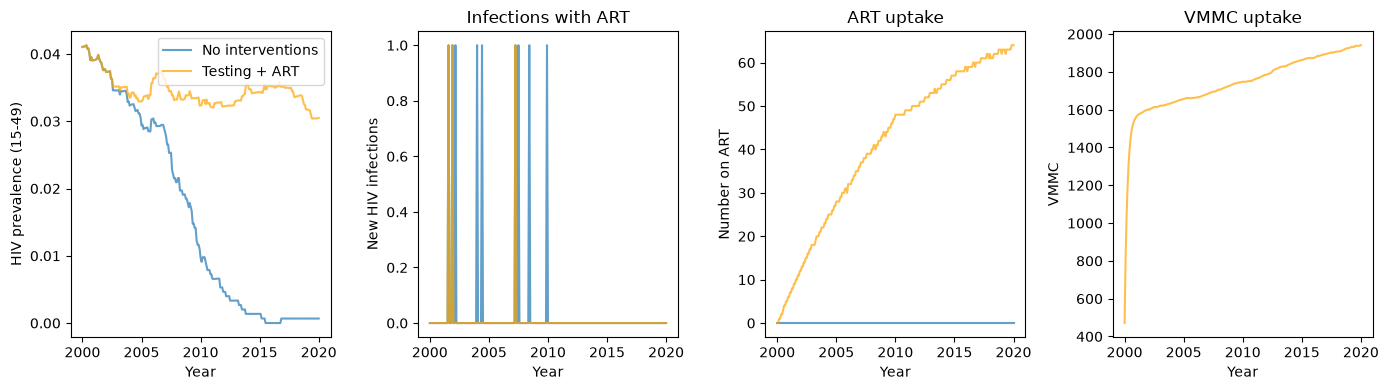

In [54]:
fig, axes = plt.subplots(1, 4, figsize=(14, 4))

axes[0].plot(sim_base.timevec, sim_base.results.hiv.prevalence_15_49, label='No interventions', alpha=0.7)
axes[0].plot(sim_intv.timevec, sim_intv.results.hiv.prevalence_15_49, label='Testing + ART', alpha=0.7, color = 'orange')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('HIV prevalence (15-49)')
axes[0].legend()

axes[1].plot(sim_intv.timevec, sim_base.results.hiv.new_infections, label='No interventions', alpha=0.7)
axes[1].plot(sim_intv.timevec, sim_intv.results.hiv.new_infections, label='Testing + ART', alpha=0.7, color = 'orange')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('New HIV infections')
axes[1].set_title('Infections with ART')

axes[2].plot(sim_intv.timevec, sim_base.results.hiv.n_on_art, label='No interventions', alpha=0.7)
axes[2].plot(sim_intv.timevec, sim_intv.results.hiv.n_on_art, label='Testing + ART', alpha=0.7, color = 'orange')
axes[2].set_xlabel('Year')
axes[2].set_ylabel('Number on ART')
axes[2].set_title('ART uptake')

axes[3].plot(sim_intv.timevec, sim_intv.results.vmmc.n_circumcised, label='Testing + ART', alpha=0.7, color = 'orange')
axes[3].set_xlabel('Year')
axes[3].set_ylabel('VMMC')
axes[3].set_title('VMMC uptake')

plt.tight_layout()

plt.show()

### Exercise 2: Run ART without HIVTesting

In [55]:
art = sti.ART(coverage={'year': [2000, 2010, 2025], 'value': [0, 0.5, 0.9]})
hiv_test = sti.HIVTest(test_prob_data=0.2, start=2000, name='hiv_test')

# With custom testing + ART
sim_intv = hivsim.demo('simple', run=False, plot=False, n_agents=3000)
sim_intv.pars.interventions = [art]
sim_intv.run(verbose=0)

Initializing sim with 3000 agents


/Users/daniel/Documents/IDM/stisim/stisim/interventions/hiv_interventions.py:278: RuntimeWarning: 
ART intervention added without an HIV testing intervention; diagnosed agents may never be identified
  ss.warn('ART intervention added without an HIV testing intervention; diagnosed agents may never be identified')


Sim(n=3000; 2000—2020.0; demographics=pregnancy, deaths; networks=mfnetwork, maternalnet, breastfeedingnet; diseases=hiv; interventions=art)

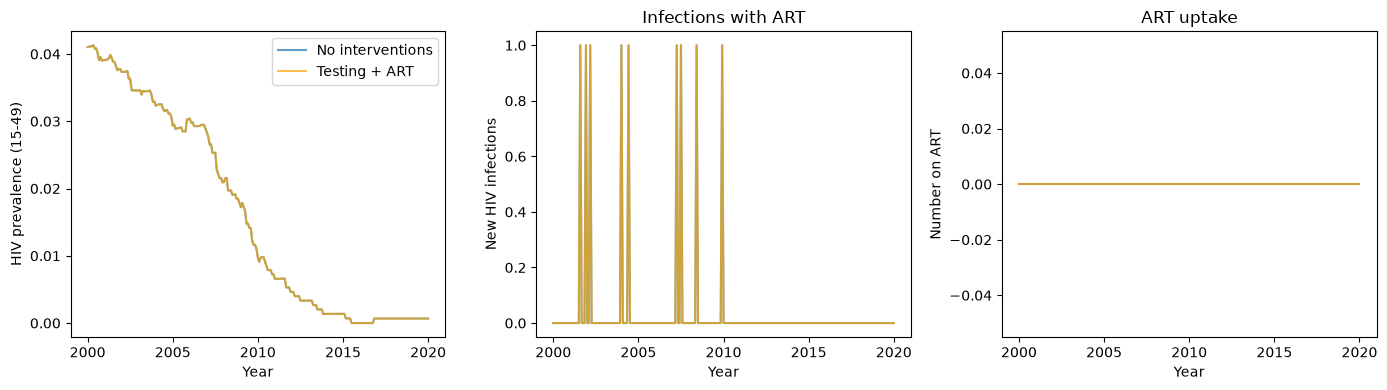

In [57]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].plot(sim_base.timevec, sim_base.results.hiv.prevalence_15_49, label='No interventions', alpha=0.7)
axes[0].plot(sim_intv.timevec, sim_intv.results.hiv.prevalence_15_49, label='Testing + ART', alpha=0.7, color = 'orange')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('HIV prevalence (15-49)')
axes[0].legend()

axes[1].plot(sim_intv.timevec, sim_base.results.hiv.new_infections, label='No interventions', alpha=0.7)
axes[1].plot(sim_intv.timevec, sim_intv.results.hiv.new_infections, label='Testing + ART', alpha=0.7, color = 'orange')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('New HIV infections')
axes[1].set_title('Infections with ART')

axes[2].plot(sim_intv.timevec, sim_base.results.hiv.n_on_art, label='No interventions', alpha=0.7)
axes[2].plot(sim_intv.timevec, sim_intv.results.hiv.n_on_art, label='Testing + ART', alpha=0.7, color = 'orange')
axes[2].set_xlabel('Year')
axes[2].set_ylabel('Number on ART')
axes[2].set_title('ART uptake')

plt.tight_layout()

plt.show()

### Exercise 3: Cmpare different ART coverages

In [59]:
art = sti.ART(coverage=0.9)
hiv_test = sti.HIVTest(test_prob_data=0.2, start=2000, name='hiv_test')

sim_intv_high = hivsim.demo('simple', run=False, plot=False, n_agents=3000)
sim_intv_high.pars.interventions = [hiv_test, art]
sim_intv_high.pars.analyzers = [sti.art_coverage(age_bins=[15, 25, 35, 45, 65])]
sim_intv_high.run(verbose=0)


art = sti.ART(coverage=0.3)
hiv_test = sti.HIVTest(test_prob_data=0.2, start=2000, name='hiv_test')

sim_intv_low = hivsim.demo('simple', run=False, plot=False, n_agents=3000)
sim_intv_low.pars.interventions = [hiv_test, art]
sim_intv_low.pars.analyzers = [sti.art_coverage(age_bins=[15, 25, 35, 45, 65])]
sim_intv_low.run(verbose=0)

Initializing sim with 3000 agents
Initializing sim with 3000 agents


Sim(n=3000; 2000—2020.0; demographics=pregnancy, deaths; networks=mfnetwork, maternalnet, breastfeedingnet; diseases=hiv; interventions=hiv_test, art; analyzers=art_coverage)

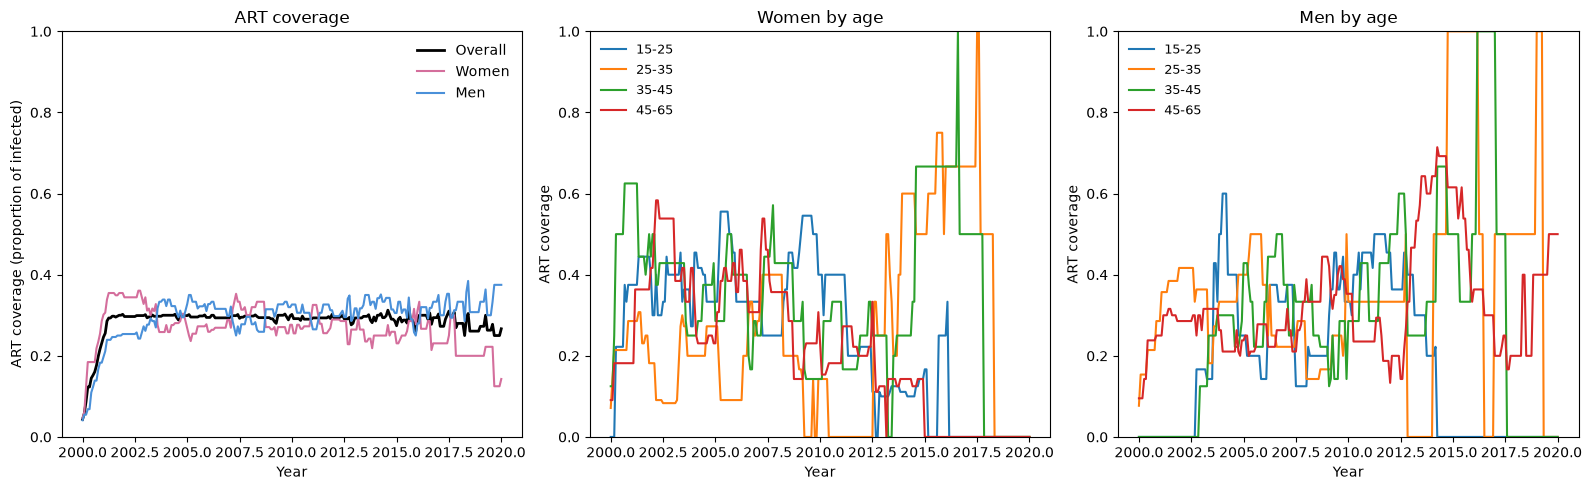

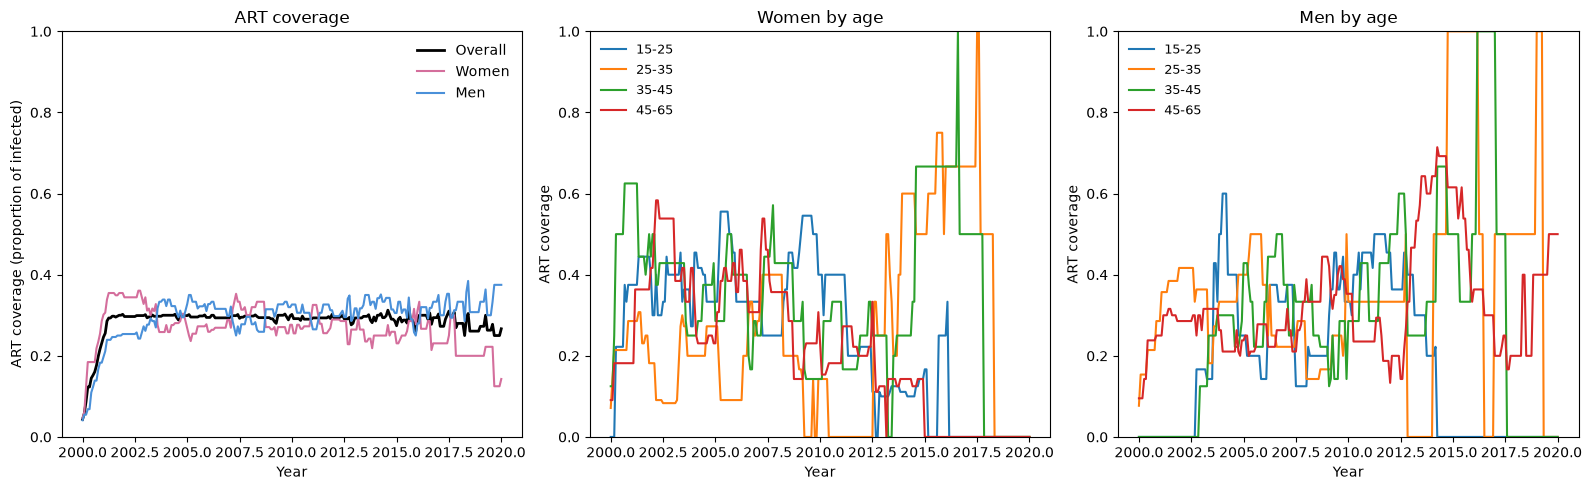

In [60]:
sim_intv_low.analyzers.art_coverage.plot()

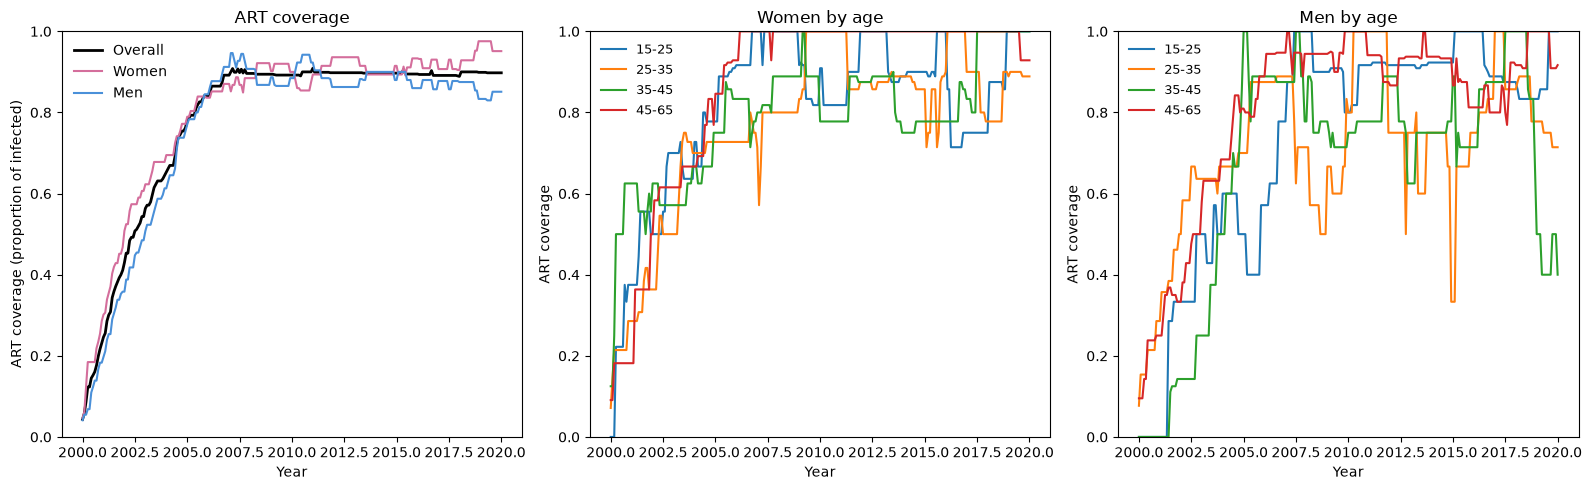

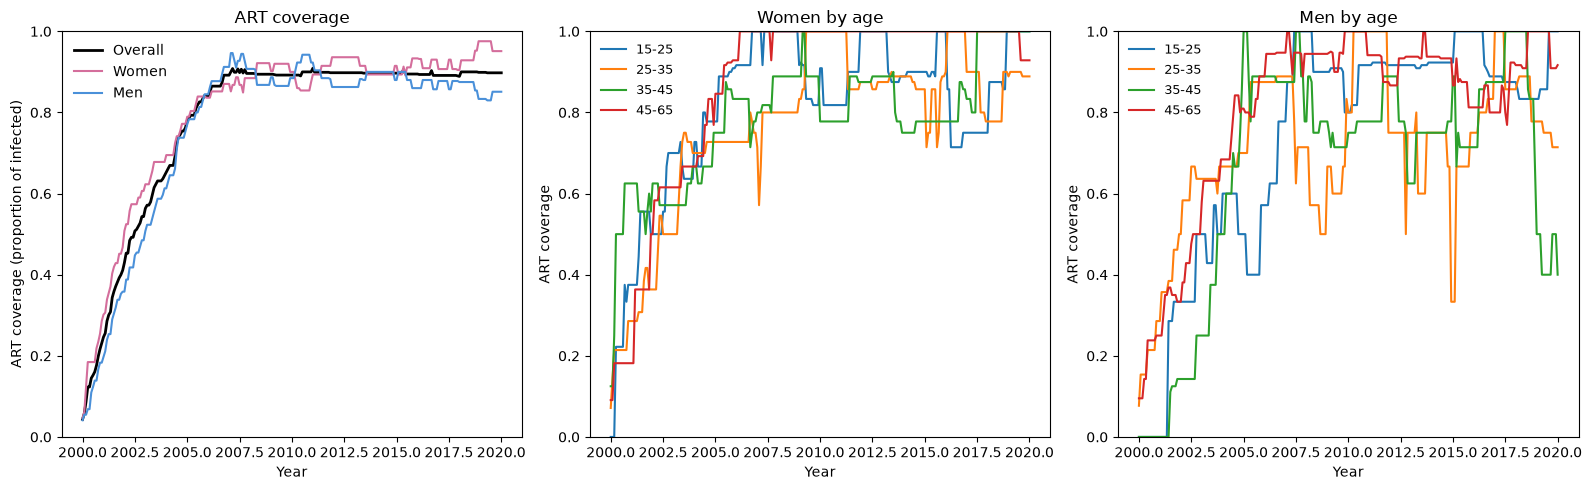

In [62]:
sim_intv_high.analyzers.art_coverage.plot()

# Part 5: Calibration

## How it works: Approximate Bayesian Computation

Uses Optuna

## Setup

Generate synthetic target data from a sim with known true parameters

In [64]:
# "True" parameters we'll try to recover
true_beta = 0.08
true_condom = 0.6

# Create and run a sim with the true parameters
true_sim = sti.Sim(
    diseases=sti.Gonorrhea(beta_m2f=true_beta, eff_condom=true_condom),
    n_agents=2000, start=2010, stop=2030,
)
true_sim.run(verbose=0)

# Extract yearly prevalence and incidence as our "data"
df = true_sim.to_df(resample='year', use_years=True, sep='.')
data = df[['timevec', 'ng.prevalence', 'ng.new_infections']].dropna()
data = data.rename(columns={'timevec': 'time'})
data['time'] = data['time'].astype(int)
print(f'Generated {len(data)} data points')
data.head()

Initializing sim with 2000 agents
Generated 21 data points


,time,ng.prevalence,ng.new_infections
0,2010,0.006135,29.0
1,2011,0.000875,6.0
2,2012,0.000967,5.0
3,2013,0.000636,1.0
4,2014,0.000000,0.0


In [65]:
## Defining calibration parameters

# Nested format -- group parameters by module (Pythonic, uses keyword syntax)
calib_pars = dict(
    ng=dict(
        beta_m2f=  dict(low=0.03, high=0.15, guess=0.06),
        eff_condom=dict(low=0.3,  high=0.9,  guess=0.5),
    ),
)

# Flat format -- equivalent, uses string keys
calib_pars_flat = {
    'ng.beta_m2f':   dict(low=0.03, high=0.15, guess=0.06),
    'ng.eff_condom':  dict(low=0.3,  high=0.9,  guess=0.5),
}

# Both produce the same result after flattening
print(sti.flatten_calib_pars(calib_pars))
print(calib_pars_flat)

{'ng.beta_m2f': {'low': 0.03, 'high': 0.15, 'guess': 0.06}, 'ng.eff_condom': {'low': 0.3, 'high': 0.9, 'guess': 0.5}}
{'ng.beta_m2f': {'low': 0.03, 'high': 0.15, 'guess': 0.06}, 'ng.eff_condom': {'low': 0.3, 'high': 0.9, 'guess': 0.5}}


In [66]:
# Multi-module example (not run here -- just to show the pattern)
multi_pars = dict(
    hiv=dict(
        beta_m2f=dict(low=0.002, high=0.014, guess=0.006),
        eff_condom=dict(low=0.5, high=0.9, guess=0.75),
    ),
    structuredsexual=dict(
        prop_f0=dict(low=0.55, high=0.9, guess=0.7),
        m1_conc=dict(low=0.05, high=0.3, guess=0.15),
    ),
    syph=dict(
        beta_m2f=dict(low=0.15, high=0.35, guess=0.2),
    ),
)
print(f'{len(sti.flatten_calib_pars(multi_pars))} parameters across 3 modules')

5 parameters across 3 modules


## Run a calibration

In [70]:
sim = sti.Sim(diseases=sti.Gonorrhea(), n_agents=500, start=2010, stop=2030, verbose=-1)

calib = sti.Calibration(
    sim=sim,
    calib_pars=calib_pars,
    data=data,
    total_trials=10,
    n_workers=1,
    verbose=False
)
calib.calibrate()
print(f'Best parameters: {calib.best_pars}')

[I 2026-07-08 15:42:16,969] A new study created in RDB with name: starsim_calibration


Initializing sim with 500 agents
  Running 2010.01.01 ( 0/241) (0.00 s)  ———————————————————— 0%
  Running 2011.01.01 (12/241) (0.03 s)  •——————————————————— 5%
  Running 2012.01.01 (24/241) (0.05 s)  ••—————————————————— 10%
  Running 2013.01.01 (36/241) (0.07 s)  •••————————————————— 15%
  Running 2014.01.01 (48/241) (0.09 s)  ••••———————————————— 20%
  Running 2015.01.01 (60/241) (0.11 s)  •••••——————————————— 25%
  Running 2016.01.01 (72/241) (0.13 s)  ••••••—————————————— 30%
  Running 2017.01.01 (84/241) (0.15 s)  •••••••————————————— 35%
  Running 2018.01.01 (96/241) (0.18 s)  ••••••••———————————— 40%
  Running 2019.01.01 (108/241) (0.20 s)  •••••••••——————————— 45%
  Running 2020.01.01 (120/241) (0.22 s)  ••••••••••—————————— 50%
  Running 2021.01.01 (132/241) (0.24 s)  •••••••••••————————— 55%
  Running 2022.01.01 (144/241) (0.26 s)  ••••••••••••———————— 60%
  Running 2023.01.01 (156/241) (0.28 s)  •••••••••••••——————— 65%
  Running 2024.01.01 (168/241) (0.30 s)  •••••••••••••

## Compare the fit

In [71]:

true_pars = {'ng.beta_m2f': true_beta, 'ng.eff_condom': true_condom}
for par, true_val in true_pars.items():
    best_val = calib.best_pars[par]
    print(f'{par}: true={true_val:.3f}, calibrated={best_val:.3f}')

ng.beta_m2f: true=0.080, calibrated=0.121
ng.eff_condom: true=0.600, calibrated=0.504


In [72]:
# Compare GOF scores: guess parameters vs best-fit parameters
calib.check_fit(do_plot=False)

Initializing sim with 500 agents
Initializing sim with 500 agents
  Running "Sim 0": 2010.01.01 ( 0/241) (0.00 s)  ———————————————————— 0%
  Running "Sim 0": 2011.01.01 (12/241) (0.03 s)  •——————————————————— 5%
  Running "Sim 0": 2012.01.01 (24/241) (0.06 s)  ••—————————————————— 10%
  Running "Sim 0": 2013.01.01 (36/241) (0.08 s)  •••————————————————— 15%
  Running "Sim 0": 2014.01.01 (48/241) (0.10 s)  ••••———————————————— 20%
  Running "Sim 0": 2010.01.01 ( 0/241) (0.00 s)  ———————————————————— 0%
  Running "Sim 0": 2015.01.01 (60/241) (0.13 s)  •••••——————————————— 25%
  Running "Sim 0": 2011.01.01 (12/241) (0.03 s)  •——————————————————— 5%
  Running "Sim 0": 2016.01.01 (72/241) (0.15 s)  ••••••—————————————— 30%
  Running "Sim 0": 2012.01.01 (24/241) (0.05 s)  ••—————————————————— 10%
  Running "Sim 0": 2017.01.01 (84/241) (0.17 s)  •••••••————————————— 35%
  Running "Sim 0": 2013.01.01 (36/241) (0.08 s)  •••————————————————— 15%
  Running "Sim 0": 2018.01.01 (96/241) (0.20 s)  •

False

Initializing sim with 500 agents
  Running 2010.01.01 ( 0/241) (0.00 s)  ———————————————————— 0%
  Running 2011.01.01 (12/241) (0.02 s)  •——————————————————— 5%
  Running 2012.01.01 (24/241) (0.05 s)  ••—————————————————— 10%
  Running 2013.01.01 (36/241) (0.07 s)  •••————————————————— 15%
  Running 2014.01.01 (48/241) (0.09 s)  ••••———————————————— 20%
  Running 2015.01.01 (60/241) (0.11 s)  •••••——————————————— 25%
  Running 2016.01.01 (72/241) (0.13 s)  ••••••—————————————— 30%
  Running 2017.01.01 (84/241) (0.15 s)  •••••••————————————— 35%
  Running 2018.01.01 (96/241) (0.17 s)  ••••••••———————————— 40%
  Running 2019.01.01 (108/241) (0.19 s)  •••••••••——————————— 45%
  Running 2020.01.01 (120/241) (0.21 s)  ••••••••••—————————— 50%
  Running 2021.01.01 (132/241) (0.23 s)  •••••••••••————————— 55%
  Running 2022.01.01 (144/241) (0.26 s)  ••••••••••••———————— 60%
  Running 2023.01.01 (156/241) (0.28 s)  •••••••••••••——————— 65%
  Running 2024.01.01 (168/241) (0.30 s)  •••••••••••••

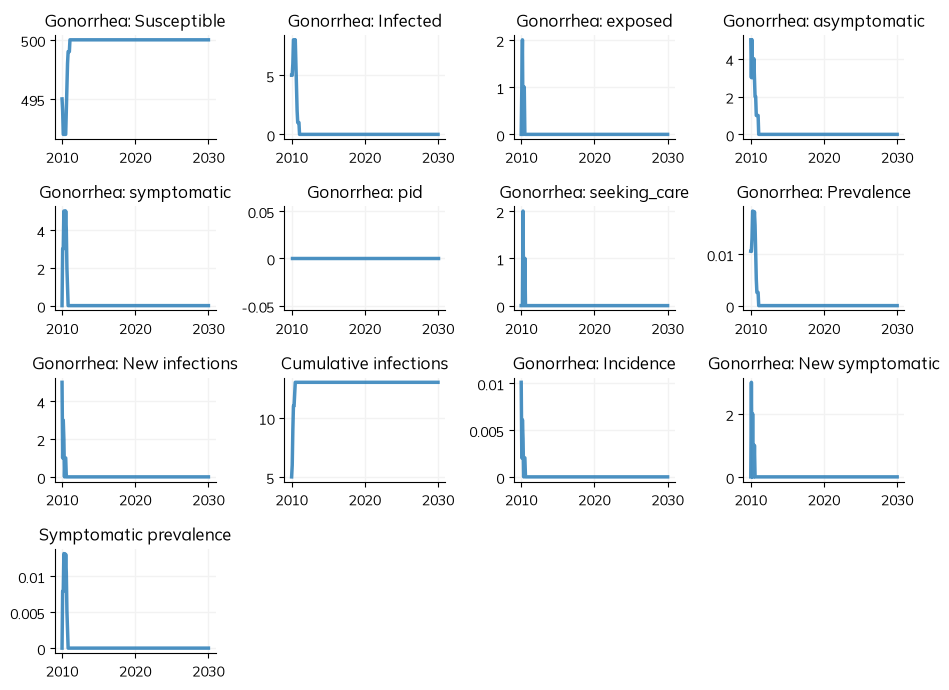

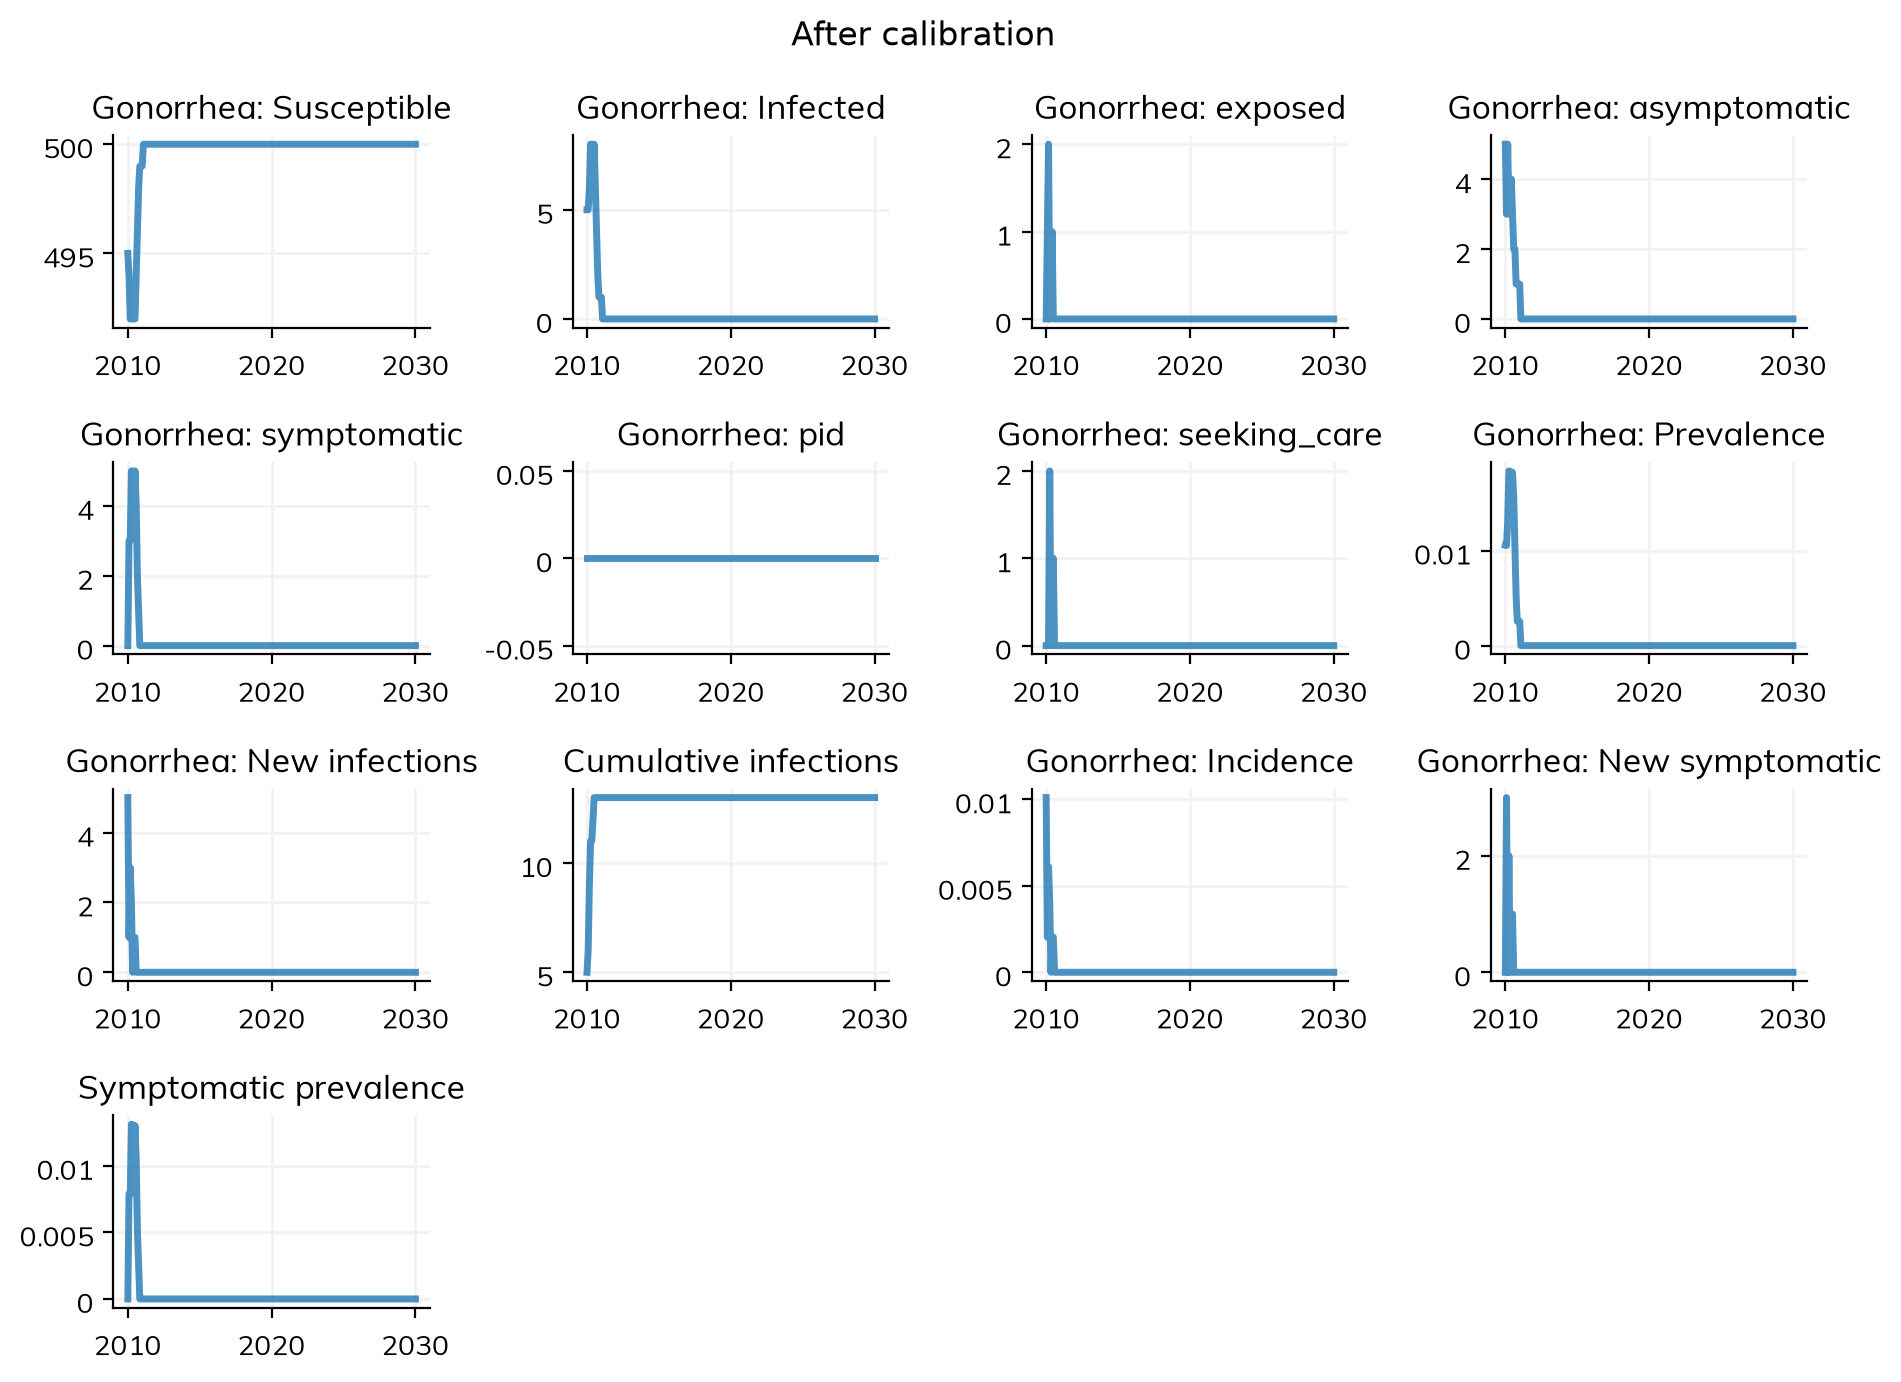

In [73]:
# Plot the sim with best-fit parameters
calib.plot_final()

## Typical calibration workflow

Has three components

1. Run calibrations - find best parameters

2. Run top parameter sets with full results

3. Run scenarios.py - compare interventions

In [83]:
# 1. run_calibrations.py -- find best parameters

sim = sti.Sim(diseases=sti.Gonorrhea(), n_agents=500, start=2010, stop=2030, verbose=-1)

calib = sti.Calibration(
    sim=sim,
    calib_pars=dict(
        ng=dict(
            beta_m2f=  dict(low=0.03, high=0.15, guess=0.06),
            eff_condom=dict(low=0.3,  high=0.9,  guess=0.5),
        ),
    ),
    data=data,
    weights={'ng.prevalence': 5.0},
    total_trials=10,   # bump to 1000-2000+ for a real calibration
    n_workers=1,
)
calib.calibrate()

os.makedirs('calib_output', exist_ok=True)
calib.save('calib_output/calib.obj')
print(f'Best parameters: {calib.best_pars}')

[I 2026-07-08 17:11:58,455] A new study created in RDB with name: starsim_calibration


Removed existing calibration file /var/folders/bd/msk_4j2n33xd2gh_w3_ts2sr0000gr/T/tmpp3i620u1/starsim_calibration.db
sqlite:////var/folders/bd/msk_4j2n33xd2gh_w3_ts2sr0000gr/T/tmpp3i620u1/starsim_calibration.db
Initializing sim with 500 agents
  Running 2010.01.01 ( 0/241) (0.00 s)  ———————————————————— 0%
  Running 2011.01.01 (12/241) (0.03 s)  •——————————————————— 5%
  Running 2012.01.01 (24/241) (0.05 s)  ••—————————————————— 10%
  Running 2013.01.01 (36/241) (0.07 s)  •••————————————————— 15%
  Running 2014.01.01 (48/241) (0.09 s)  ••••———————————————— 20%
  Running 2015.01.01 (60/241) (0.11 s)  •••••——————————————— 25%
  Running 2016.01.01 (72/241) (0.13 s)  ••••••—————————————— 30%
  Running 2017.01.01 (84/241) (0.15 s)  •••••••————————————— 35%
  Running 2018.01.01 (96/241) (0.17 s)  ••••••••———————————— 40%
  Running 2019.01.01 (108/241) (0.19 s)  •••••••••——————————— 45%
  Running 2020.01.01 (120/241) (0.21 s)  ••••••••••—————————— 50%
  Running 2021.01.01 (132/241) (0.23 s) 

[I 2026-07-08 17:11:59,023] Trial 0 finished with value: 4.527931525854567 and parameters: {'ng.beta_m2f': 0.11800953418816024, 'ng.eff_condom': 0.3562571036699481, 'rand_seed': 56737}. Best is trial 0 with value: 4.527931525854567.


  Running 2022.01.01 (144/241) (0.25 s)  ••••••••••••———————— 60%
  Running 2023.01.01 (156/241) (0.27 s)  •••••••••••••——————— 65%
  Running 2024.01.01 (168/241) (0.29 s)  ••••••••••••••—————— 70%
  Running 2025.01.01 (180/241) (0.31 s)  •••••••••••••••————— 75%
  Running 2026.01.01 (192/241) (0.34 s)  ••••••••••••••••———— 80%
  Running 2027.01.01 (204/241) (0.36 s)  •••••••••••••••••——— 85%
  Running 2028.01.01 (216/241) (0.38 s)  ••••••••••••••••••—— 90%
  Running 2029.01.01 (228/241) (0.40 s)  •••••••••••••••••••— 95%
  Running 2030.01.01 (240/241) (0.42 s)  •••••••••••••••••••• 100%

Initializing sim with 500 agents
  Running 2010.01.01 ( 0/241) (0.00 s)  ———————————————————— 0%
  Running 2011.01.01 (12/241) (0.03 s)  •——————————————————— 5%
  Running 2012.01.01 (24/241) (0.05 s)  ••—————————————————— 10%
  Running 2013.01.01 (36/241) (0.08 s)  •••————————————————— 15%
  Running 2014.01.01 (48/241) (0.10 s)  ••••———————————————— 20%
  Running 2015.01.01 (60/241) (0.13 s)  •••••———

[I 2026-07-08 17:11:59,592] Trial 1 finished with value: 35.381429604884325 and parameters: {'ng.beta_m2f': 0.10070667136699549, 'ng.eff_condom': 0.7221568112129819, 'rand_seed': 48804}. Best is trial 0 with value: 4.527931525854567.


...

[I 2026-07-08 17:12:03,603] Trial 8 finished with value: 13.420846264101295 and parameters: {'ng.beta_m2f': 0.09300860986353632, 'ng.eff_condom': 0.6661021647964391, 'rand_seed': 883902}. Best is trial 3 with value: 4.304061740294006.


Initializing sim with 500 agents
  Running 2010.01.01 ( 0/241) (0.00 s)  ———————————————————— 0%
  Running 2011.01.01 (12/241) (0.02 s)  •——————————————————— 5%
  Running 2012.01.01 (24/241) (0.04 s)  ••—————————————————— 10%
  Running 2013.01.01 (36/241) (0.07 s)  •••————————————————— 15%
  Running 2014.01.01 (48/241) (0.09 s)  ••••———————————————— 20%
  Running 2015.01.01 (60/241) (0.11 s)  •••••——————————————— 25%
  Running 2016.01.01 (72/241) (0.13 s)  ••••••—————————————— 30%
  Running 2017.01.01 (84/241) (0.15 s)  •••••••————————————— 35%
  Running 2018.01.01 (96/241) (0.17 s)  ••••••••———————————— 40%
  Running 2019.01.01 (108/241) (0.19 s)  •••••••••——————————— 45%
  Running 2020.01.01 (120/241) (0.21 s)  ••••••••••—————————— 50%
  Running 2021.01.01 (132/241) (0.23 s)  •••••••••••————————— 55%
  Running 2022.01.01 (144/241) (0.25 s)  ••••••••••••———————— 60%
  Running 2023.01.01 (156/241) (0.27 s)  •••••••••••••——————— 65%
  Running 2024.01.01 (168/241) (0.29 s)  •••••••••••••

[I 2026-07-08 17:12:04,141] Trial 9 finished with value: 3.597037194509136 and parameters: {'ng.beta_m2f': 0.10476352299326797, 'ng.eff_condom': 0.39955885413238723, 'rand_seed': 445154}. Best is trial 9 with value: 3.597037194509136.


  Running 2029.01.01 (228/241) (0.39 s)  •••••••••••••••••••— 95%
  Running 2030.01.01 (240/241) (0.41 s)  •••••••••••••••••••• 100%

Making results structure...
Processed 10 trials; 0 failed
Best pars: {'ng.beta_m2f': 0.10476352299326797, 'ng.eff_condom': 0.39955885413238723, 'rand_seed': 445154}
Removed existing calibration file /var/folders/bd/msk_4j2n33xd2gh_w3_ts2sr0000gr/T/tmpp3i620u1/starsim_calibration.db


NameError: name 'os' is not defined

In [84]:
# 2. run_msim.py -- run top parameter sets with full results
pars_df = calib.df

sim = sti.Sim(diseases=sti.Gonorrhea(), n_agents=500, start=2010, stop=2030, verbose=-1)
msim = sti.make_calib_sims(
    calib_pars=pars_df, sim=sim, n_parsets=3,
)
print(f'Ran {len(msim.sims)} simulations with top parameter sets')

Initializing sim "Sim 0" with 500 agents
Initializing sim "Sim 1" with 500 agents
Initializing sim "Sim 2" with 500 agents
  Running "Sim 0": 2010.01.01 ( 0/241) (0.00 s)  ———————————————————— 0%
  Running "Sim 1": 2010.01.01 ( 0/241) (0.00 s)  ———————————————————— 0%
  Running "Sim 2": 2010.01.01 ( 0/241) (0.00 s)  ———————————————————— 0%
  Running "Sim 0": 2011.01.01 (12/241) (0.03 s)  •——————————————————— 5%
  Running "Sim 1": 2011.01.01 (12/241) (0.03 s)  •——————————————————— 5%
  Running "Sim 2": 2011.01.01 (12/241) (0.03 s)  •——————————————————— 5%
  Running "Sim 0": 2012.01.01 (24/241) (0.05 s)  ••—————————————————— 10%
  Running "Sim 1": 2012.01.01 (24/241) (0.05 s)  ••—————————————————— 10%
  Running "Sim 2": 2012.01.01 (24/241) (0.05 s)  ••—————————————————— 10%
  Running "Sim 0": 2013.01.01 (36/241) (0.08 s)  •••————————————————— 15%
  Running "Sim 1": 2013.01.01 (36/241) (0.08 s)  •••————————————————— 15%
  Running "Sim 2": 2013.01.01 (36/241) (0.08 s)  •••—————————————————

In [85]:
# 3. run_scenarios.py -- compare interventions
for scenario in ['baseline', 'intervention']:
    if scenario == 'intervention':
        # Treat symptomatic care-seekers -- see care-seeking discussion for
        # why `seeking_care` is the right flag (fires once, the timestep
        # someone's care-seeking delay elapses).
        interventions = [sti.GonorrheaTreatment(
            eligibility=lambda sim: sim.diseases.ng.seeking_care,
        )]
    else:
        interventions = []

    sim = sti.Sim(diseases=sti.Gonorrhea(), n_agents=500, start=2010, stop=2030,
                  verbose=-1, interventions=interventions)
    msim = sti.make_calib_sims(
        calib_pars=pars_df, sim=sim,
        n_parsets=3, seeds_per_par=2,
    )
    print(f'[{scenario}] ran {len(msim.sims)} simulations')

Initializing sim "Sim 0" with 500 agents
Initializing sim "Sim 2" with 500 agents
Initializing sim "Sim 1" with 500 agents
Initializing sim "Sim 3" with 500 agents
Initializing sim "Sim 4" with 500 agents
Initializing sim "Sim 5" with 500 agents
  Running "Sim 0": 2010.01.01 ( 0/241) (0.00 s)  ———————————————————— 0%
  Running "Sim 2": 2010.01.01 ( 0/241) (0.00 s)  ———————————————————— 0%
  Running "Sim 1": 2010.01.01 ( 0/241) (0.00 s)  ———————————————————— 0%
  Running "Sim 3": 2010.01.01 ( 0/241) (0.00 s)  ———————————————————— 0%
  Running "Sim 0": 2011.01.01 (12/241) (0.04 s)  •——————————————————— 5%
  Running "Sim 2": 2011.01.01 (12/241) (0.04 s)  •——————————————————— 5%

  Running "Sim 5": 2010.01.01 ( 0/241) (0.00 s)  ———————————————————— 0%

  Running "Sim 3": 2011.01.01 (12/241) (0.04 s)  •——————————————————— 5%
  Running "Sim 1": 2012.01.01 (24/241) (0.06 s)  ••—————————————————— 10%
  Running "Sim 2": 2012.01.01 (24/241) (0.07 s)  ••—————————————————— 10%
  Running "Sim 0": 2